# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Kalkstein 90°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 342
Average Fx in the averaging interval [1377:1719]: 4.6907520712467665
Average Fz in the averaging interval [1377:1719]: 0.7954745465551901
Maximum Fz in the plotting interval [1377:None]: 1.6356038411458333 at timestep 1698
Time step where Fx drops below 1: 1720


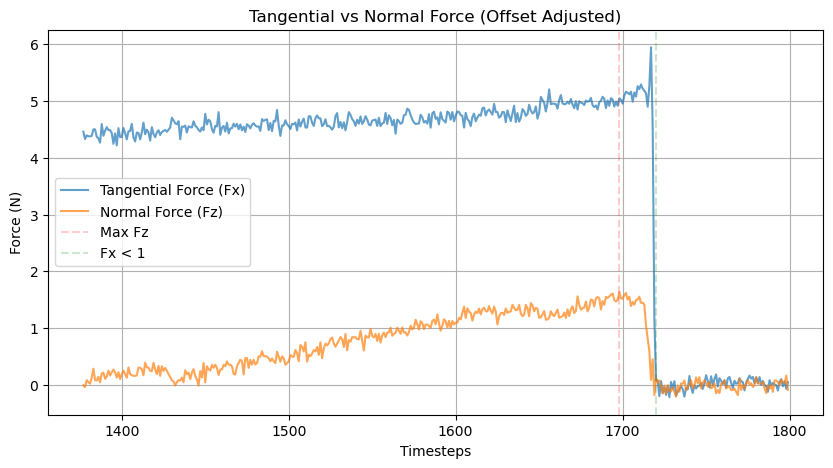

In [64]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231835.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=1377, cut_2=None, avg_end=1719, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 749
Average Fx in the averaging interval [880:1629]: 6.226608322544208
Average Fz in the averaging interval [880:1629]: 0.7522024157209612
Maximum Fz in the plotting interval [880:None]: 1.721484375 at timestep 1610
Time step where Fx drops below 1: 1629


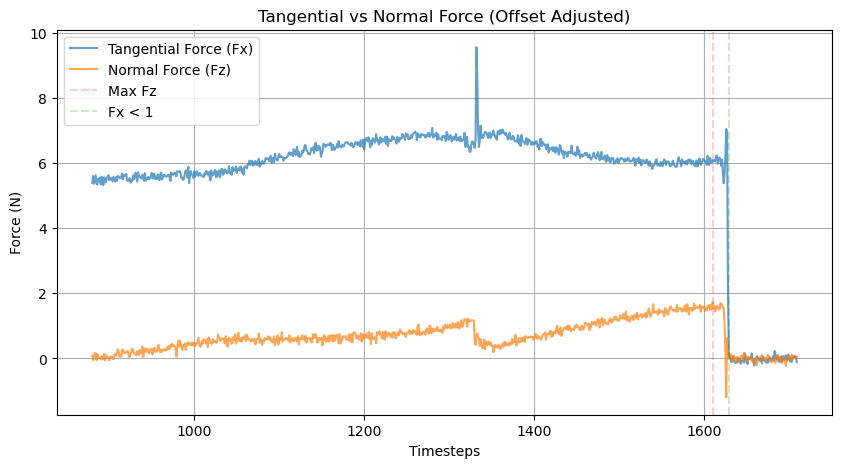

In [65]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231837.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=880, cut_2=None, avg_end=1629, offset_position='end', offset_length=15)

<font size="6">Test 3: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.8935320978058114
Average Fz in the averaging interval [None:None]: -1.5950957399506809
Maximum Fz in the plotting interval [None:None]: 0.18372802734375 at timestep 11
Time step where Fx drops below 1: 0


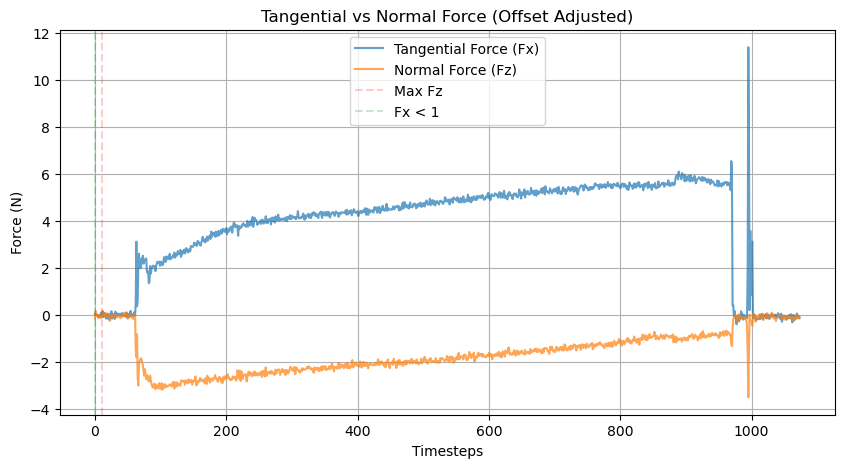

In [66]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231838.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 4: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.15498701722749
Average Fz in the averaging interval [None:None]: -1.1213940958989668
Maximum Fz in the plotting interval [None:None]: 0.20575764973958333 at timestep 1054
Time step where Fx drops below 1: 0


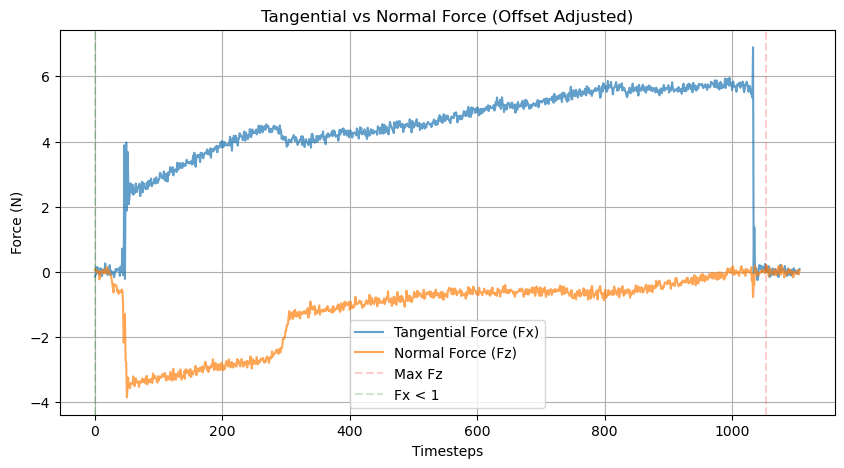

In [67]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231839.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 5: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.262213886271039
Average Fz in the averaging interval [None:None]: -1.082544990710433
Maximum Fz in the plotting interval [None:None]: 0.27178548177083334 at timestep 36
Time step where Fx drops below 1: 0


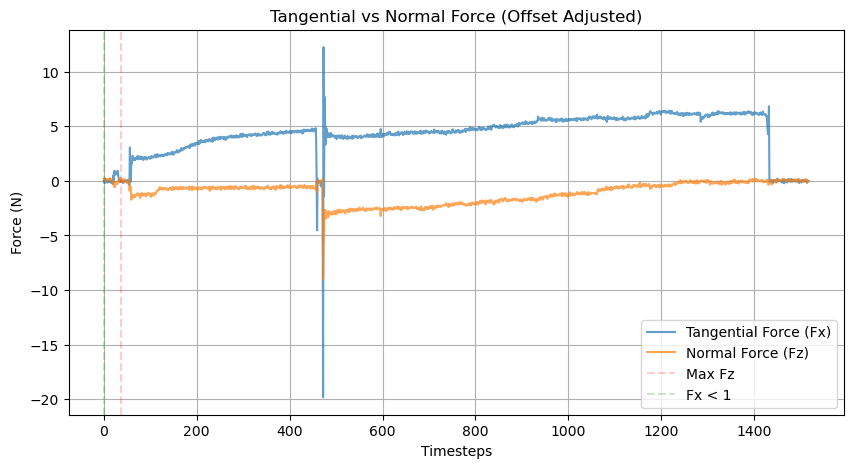

In [68]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231840.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 198
Average Fx in the averaging interval [820:1018]: 5.84507340517911
Average Fz in the averaging interval [820:1018]: 0.29452292702414773
Maximum Fz in the plotting interval [820:1038]: 0.7499755859375 at timestep 1002
Time step where Fx drops below 1: 1019


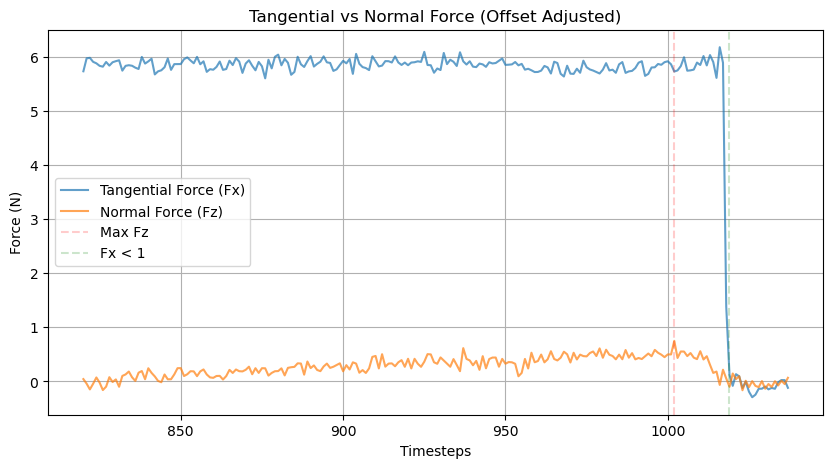

In [69]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231841.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=820, cut_2=1038, avg_end=1018, offset_position='beginning', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 585
Average Fx in the averaging interval [1280:1865]: 5.9712652915563345
Average Fz in the averaging interval [1280:1865]: 0.9364781567174145
Maximum Fz in the plotting interval [1280:None]: 2.219901529947917 at timestep 1845
Time step where Fx drops below 1: 1865


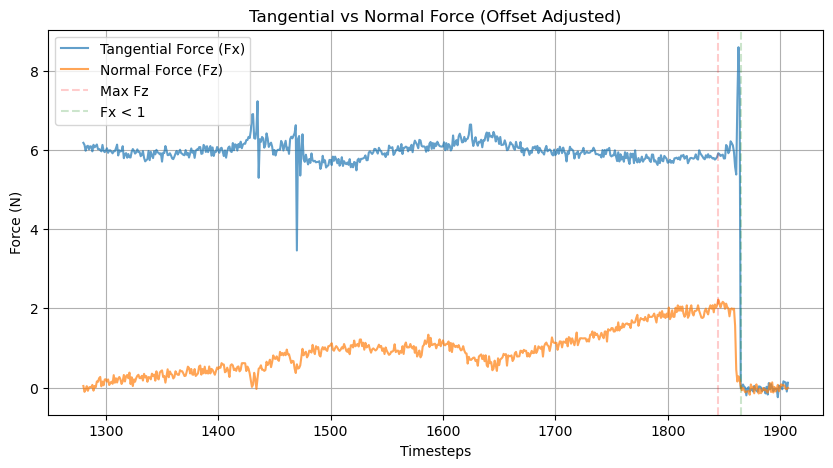

In [70]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231843.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=1280, cut_2=None, avg_end=1865, offset_position='end', offset_length=15)

<font size="6">Test 8: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.2744499582958353
Average Fz in the averaging interval [None:None]: -0.6234507753592987
Maximum Fz in the plotting interval [None:None]: 0.24660237630208331 at timestep 886
Time step where Fx drops below 1: 0


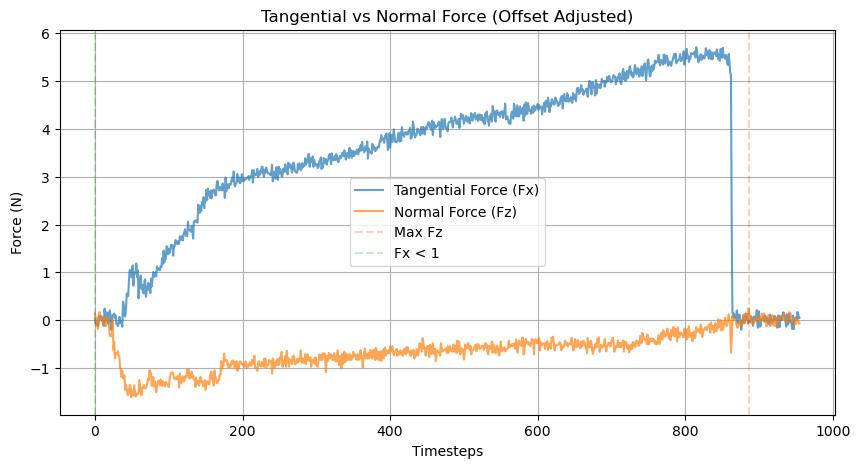

In [71]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231844.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 9: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.135136357424773
Average Fz in the averaging interval [None:None]: -1.738929237388823
Maximum Fz in the plotting interval [None:None]: 0.17968343098958334 at timestep 4
Time step where Fx drops below 1: 0


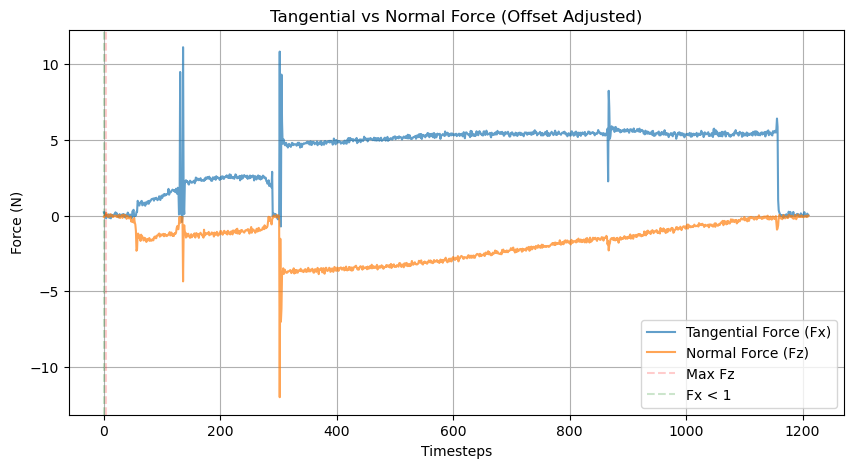

In [72]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231845.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 10a: (worked)</font>

Length from cut_1 to avg_end: 251
Average Fx in the averaging interval [600:851]: 5.501681042730729
Average Fz in the averaging interval [600:851]: 0.17728696217733234
Maximum Fz in the plotting interval [600:867]: 0.6383504231770833 at timestep 829
Time step where Fx drops below 1: 851


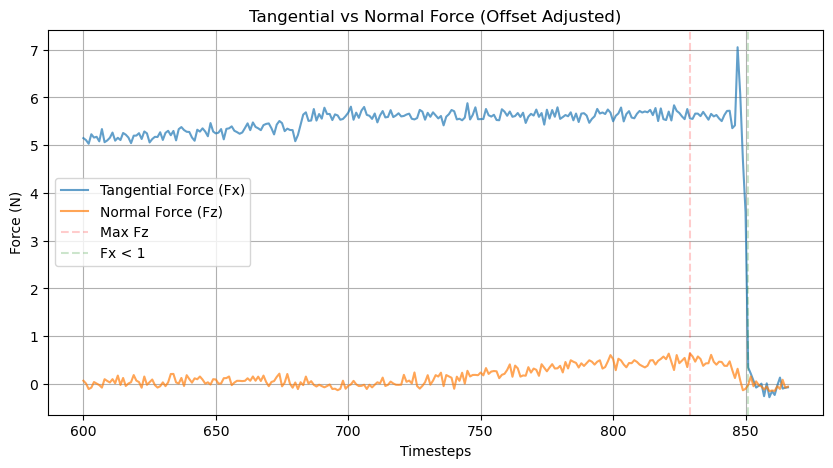

In [73]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231847.csv"
df = pd.read_csv(data)
test_10a, end_10a = plot_forces(df, cut_1=600, cut_2=867, avg_end=851, offset_position='end', offset_length=15)

<font size="6">Test 10b: (worked)</font>

Length from cut_1 to avg_end: 163
Average Fx in the averaging interval [1658:1821]: 5.877318910197003
Average Fz in the averaging interval [1658:1821]: 0.5763604224581416
Maximum Fz in the plotting interval [1658:1850]: 1.0232381184895833 at timestep 1791
Time step where Fx drops below 1: 1821


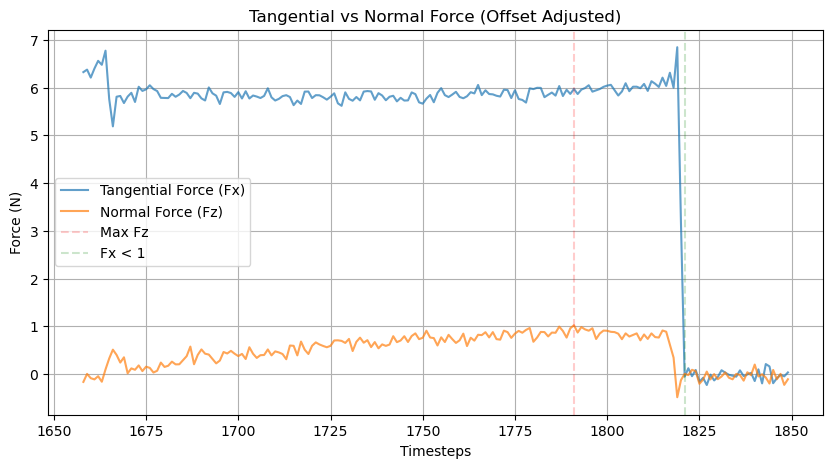

In [74]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_90_5N//log_202405231847.csv"
df = pd.read_csv(data)
test_10b, end_10b = plot_forces(df, cut_1=1658, cut_2=1850, avg_end=1821, offset_position='end', offset_length=15)

In [75]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [79]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//90//Kalkstein_90_stats.csv", index=False)

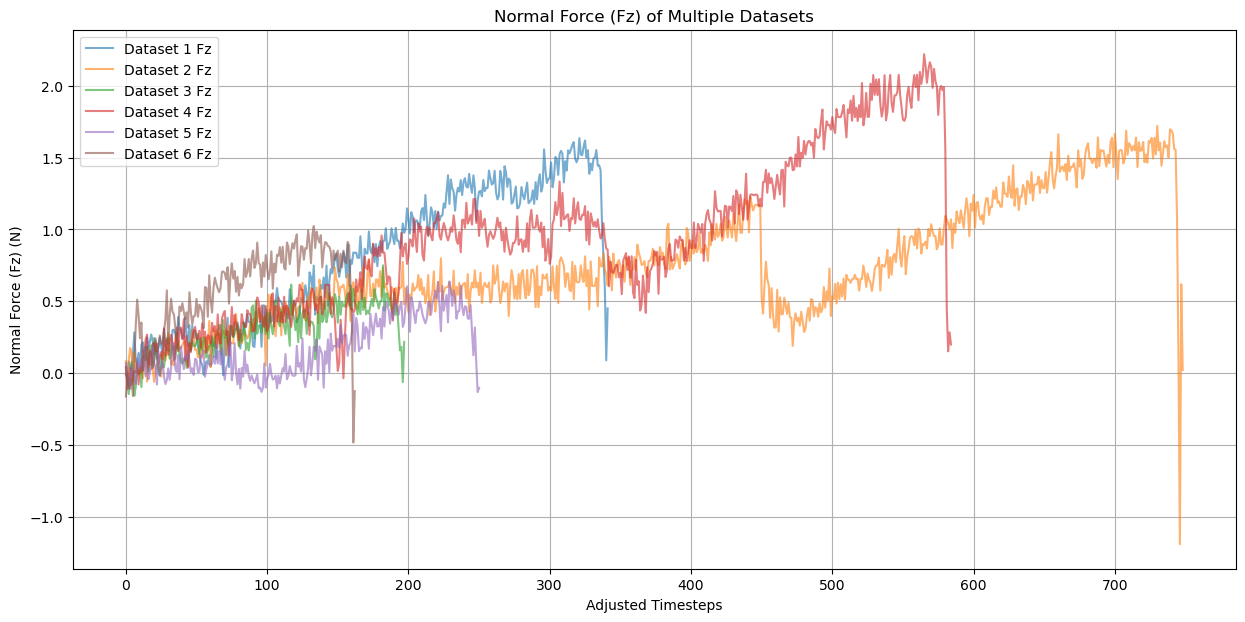

Average of maximum Fz forces: 1.3314256456163196
Standard deviation of maximum Fz forces: 0.5697187276453485
Average of average Fz forces: 0.5887209051088647
Standard deviation of average Fz forces: 0.2727610370044149
Average of average Fx forces: 5.685449840575692
Standard deviation of average Fx forces: 0.49329352658924247


In [80]:
tests = [test_1, test_2, test_6, test_7, test_10a, test_10b]
ends = [end_1, end_2, end_6, end_7, end_10a, end_10b]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [81]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//90//Kalkstein_90"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)